# Linear Regression

In [1]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 200 #num of instances
X = 2 * rng.random((m , 1)) #X => column vector
y = 4 + 3 * X + rng.standard_normal((m , 1)) #y => column vector

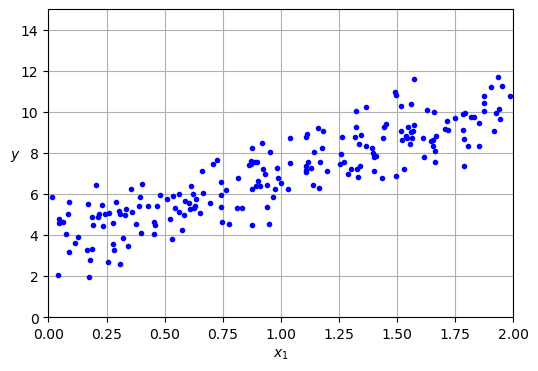

In [2]:
#visual representation of randomly generated linear dataset
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

Lets compute theta-dash using the normal equation. (Theta-dash is the vector of theta that minimizes the cost function)

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) #add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y #the @ operator performs a matrix mul

In [4]:
#Print theta0 and theta1:
theta_best

array([[3.69084138],
       [3.32960458]])

Now lets make predictions using theta-dash:

In [5]:
X_new = np.array([[0] , [2]])
X_new_b = add_dummy_feature(X_new) #add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

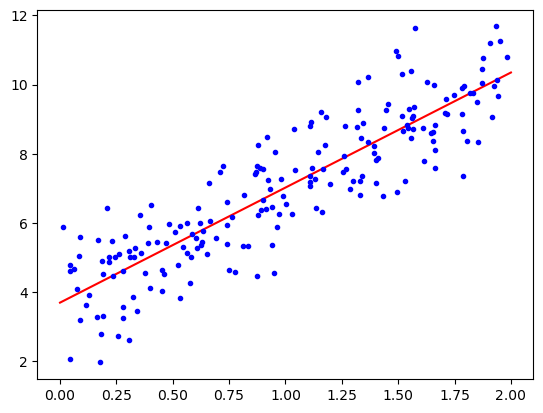

In [6]:
#plotting this model's predictions:
plt.plot(X_new , y_predict , "r-" , label="Predictions")
plt.plot(X , y , "b.")
plt.show()

## Linear regression using Scikit-Learn

In [7]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X , y)
lin_reg.intercept_ , lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [8]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

# Gradient Descent

Batch Gradient Descent implementation:

In [9]:
eta = 0.1 #learning rate
n_epochs = 1000 #num of rounds
m = len(X_b)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2 , 1)) #randomly initialized model parameters

for epoch in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta - y) #formula calculates the gradient vector of the cost func
    theta = theta - eta * gradients
    
theta

array([[3.69084138],
       [3.32960458]])

=> exactly like with Linear Regressin via normal equation.

## Stochastic Gradient Descent

An implementation of SGD with a simple learning schedule:

In [10]:
n_epochs = 50
t0 , t1 = 5 , 50 #learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1) #learning rate gets smaller and smaller over time

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2 , 1)) #randomly initialized model parameters

for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        
        #pick a random sample
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        
        gradients = 2 * xi.T @ (xi @ theta - yi) #for SGD, no div by m since it is only one sample
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        
theta

array([[3.69826475],
       [3.30748311]])

=> Theta is not exact but sufficient

## Scikit-learn's Stochastic Gradient Descent

Using SGDRegressor which runs for a maximum of 1000 epochs, or until the loss drops by less than 10^-5 during 100 epochs. I starts with learning rate of 0.01 using the default learning schedule.

In [11]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000 , tol=1e-5 , penalty=None , eta0=0.01,
                      n_iter_no_change=100 , random_state=42)
sgd_reg.fit(X , y.ravel()) #y.ravel() because fit() excepts 1D targets
sgd_reg.intercept_ , sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

# Polynomial Regression

In [12]:
#generate some random non-linear data
rng = np.random.default_rng(seed=42)
m = 200 # num instances
X = 6 * rng.random((m , 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m , 1))

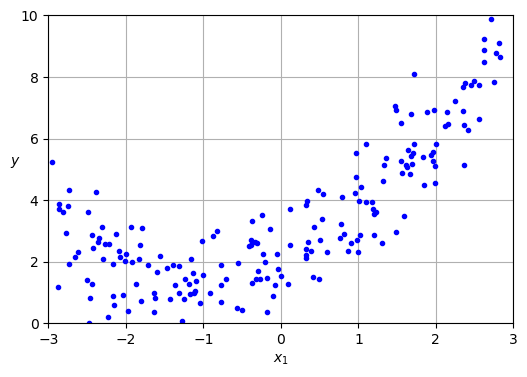

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()

=> Linear line will not fit this data. With 'PolynomialFeatures' class, we will transform our training data by adding the square of each feature in the set as a new feature.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2 , include_bias=False)
X_poly = poly_features.fit_transform(X)

print(X[0])
print(X_poly[0])

[1.64373629]
[1.64373629 2.701869  ]


=> Now we can fit a LinearRegression model to this extended training data

In [15]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly , y)
lin_reg.intercept_ , lin_reg.coef_

(array([2.00540719]), array([[1.11022126, 0.50526985]]))

Using Scikit-Learn's learning_curve() to check the performance of a (!) linear (!) model

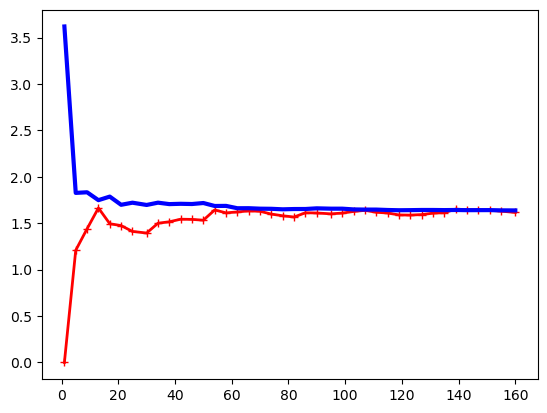

In [16]:
from sklearn.model_selection import learning_curve

train_sizes , train_scores , valid_scores = learning_curve(LinearRegression() , X , y , 
                                                           train_sizes=np.linspace(0.01 , 1.0 , 40) ,
                                                           cv=5 , scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes , train_errors , "r-+" , linewidth=2 , label="train")
plt.plot(train_sizes , valid_errors , "b-" , linewidth=3 , label="valid")
plt.show()

=> This model is too simple. It is underfitting the data. That is why we used a polynomial model

Now lets use a 10th-degree polynomial model on the same data and check how it performs.

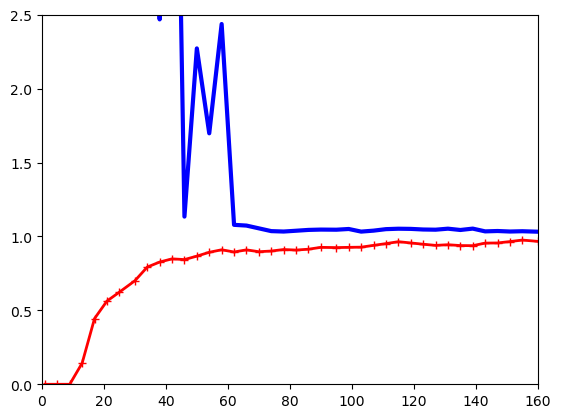

In [17]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10 , include_bias=False),
    LinearRegression()
)

train_sizes , train_scores , valid_scores = learning_curve(polynomial_regression , X , y ,
                                                          train_sizes=np.linspace(0.01 , 1.0 , 40) ,
                                                          cv=5 , scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)

plt.plot(train_sizes , train_errors , "r-+" , linewidth=2 , label="train")
plt.plot(train_sizes , valid_errors , "b-" , linewidth=3 , label="valid")
plt.axis([0, 160, 0, 2.5])
plt.show()


The error on the training data is much lower than on the linear model. But this model is overfitting as it has a larger error on the validation data than on the training data.

# Regularized Linear Models

## Ridge Regression

Perform a ridge regression with Scikit'Learn lib. Using a closed-form solution.

In [18]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1 , solver="cholesky")
ridge_reg.fit(X , y)
ridge_reg.predict([[1.5]])

array([[5.06157854]])

Or by using a stochastic gradient descent. Specifying "l2" for penalty hyperparameter selects that the regularization term is added to the mean squared error cost function. There is no division by m in this case. That is why we need to pass alpha=0.1/m

In [19]:
sgd_reg = SGDRegressor(penalty="l2" , alpha=0.1 / m , tol=None ,
                      max_iter=1000 , eta0=0.01 , random_state=42)
sgd_reg.fit(X , y.ravel()) #fit excepts 1D targets
sgd_reg.predict([[1.5]])

array([5.06208065])

## Lasso Regression

Example with Scikit-Learn functions. We could also use SGDRegressor(penalty="l1" , alpha=0.1) instead.

In [20]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X , y)
lasso_reg.predict([[1.5]])

array([5.00803756])

## Elastic Net Regression

Elastic Net Regression is a middle ground between ridge regression and lasso regression. We can control the ratio by changing a parameter.

In [21]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1 , l1_ratio=0.5) #weight ridge regression and lasso regression 50/50
elastic_net.fit(X , y)
elastic_net.predict([[1.5]])

array([5.006944])

## Early Stopping

Idea: Stop training as soon as the validation error reaches the minimum. Here comes a basic implementation:

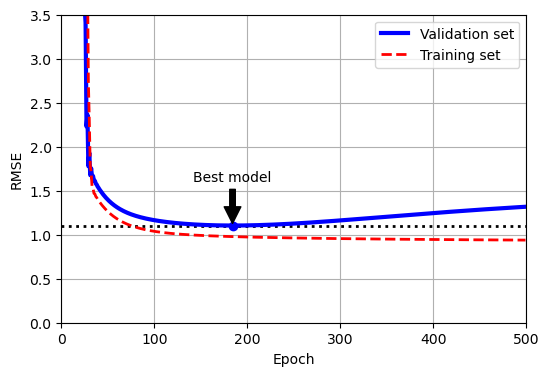

In [22]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
rng = np.random.default_rng(seed=42)
m = 200  # number of instances
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

# extra code – this section generates Figure 4–20
best_epoch = np.argmin(val_errors)
plt.figure(figsize=(6, 4))
plt.annotate('Best model',
             xy=(best_epoch, best_valid_rmse),
             xytext=(best_epoch, best_valid_rmse + 0.5),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05))
plt.plot([0, n_epochs], [best_valid_rmse, best_valid_rmse], "k:", linewidth=2)
plt.plot(val_errors, "b-", linewidth=3, label="Validation set")
plt.plot(best_epoch, best_valid_rmse, "bo")
plt.plot(train_errors, "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.axis([0, n_epochs, 0, 3.5])
plt.grid()

plt.show()

# Logistic Regression

Logistic Regression works like a normal linear regression model: It computes a weighted sum of the input features plus a bias term. But instead of outputting the result directly, it outputs the logistic of this result.

Try the LogReg classifier to detect the Iris virginica on the famous iris dataset.

In [23]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [24]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [25]:
iris.target.head(3) #instances are not shuffled

0    0
1    0
2    0
Name: target, dtype: int64

In [26]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica' #we are only interested to detect iris virginica

#split set
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state=42)

#train
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train , y_train)

LogisticRegression(random_state=42)

Let's look at the model's estimated probabilities for flowers with petal widths varying from 0cm to 3cm.

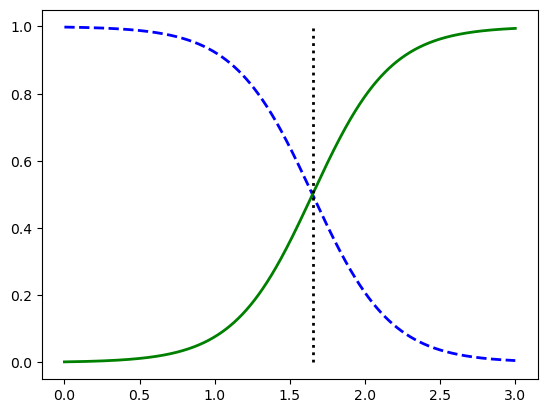

In [29]:
X_new = np.linspace(0 , 3 , 1000).reshape(-1 , 1) #get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[: , 1] >= 0.5][0 , 0]

plt.plot(X_new , y_proba[: , 0] , "b--" , linewidth=2 , label="Not Iris virginica proba")
plt.plot(X_new , y_proba[: , 1] , "g-" , linewidth=2 , label="Iris virginica proba")
plt.plot([decision_boundary , decision_boundary] , [0 , 1] , "k:" , linewidth=2 , label="Decision boundary")
plt.show()

In [30]:
decision_boundary

1.6516516516516517

In [32]:
#Question: Is the iris a virginica for a given petal width?
log_reg.predict([[1.7] , [1.5] , [1.651]])

array([ True, False,  True])

## Softmax Regression (multinomial logistic regression)

Is used to support multiple classes (instead of a binary classifier like LogReg). 
The softmax regression classifier predicts only one class at a time. So it should be used only with mutually exclusive classes.

Using Scikit-Learn's softmax regression to classify the iris platns into all three classes. Scikit's LogisticRegression is using Softmax Regression automatically when trained on more than 2 classes.

In [33]:
X = iris.data[["petal length (cm)" , "petal width (cm)"]].values
y = iris["target"]
X_train , X_test , y_train , y_test = train_test_split(X , y , random_state=42)

softmax_reg = LogisticRegression(C=30 , random_state=42)
softmax_reg.fit(X_train , y_train)

LogisticRegression(C=30, random_state=42)

In [34]:
softmax_reg.predict([[5 , 3]]) #given petals that are 5cm long and 2cm wide -> what class do we have?

array([2])

In [35]:
softmax_reg.predict_proba([[5 , 2]]).round(2)

array([[0.  , 0.04, 0.96]])

=> 96% class 2 (Iris virginica) | 4% class 1 (Iris versicolor)